In [ ]:
import sqlite3
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from tqdm.notebook import tqdm
import gc
import json

plt.style.use("ggplot")

In [2]:
# Connect to database
conn = sqlite3.connect("mimic.db")

# Confirm connection
pd.read_sql("PRAGMA database_list;", conn)

,seq,name,file
0,0,main,/blue/cap5771/shesadree.p/CAP5771_lili1501/mim...


In [3]:
conn.execute("PRAGMA foreign_keys = ON;")

In [30]:
icu_df = pd.read_sql("SELECT * FROM icu_features;", conn)
icu_df.rename(columns={"hospital_expire_flag": "mortality_icu"}, inplace=True)
icu_df.head()

,stay_id,age,gender,race,admission_location,first_careunit,mortality_icu,los,max_hr,min_hr,...,max_potassium,min_potassium,mean_potassium,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h
0,39765666,73,F,BLACK/AFRICAN AMERICAN,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),0,0.497535,80.0,68.0,...,4.5,4.2,4.300000,46.0,38.0,41.500000,223.0,188.0,212.500000,4300.0
1,37067082,55,F,WHITE,EMERGENCY ROOM,Surgical Intensive Care Unit (SICU),0,1.118032,106.0,78.0,...,3.9,3.6,3.733333,9.0,7.0,8.000000,362.0,285.0,312.666667,2745.0
2,34592300,55,F,WHITE,PHYSICIAN REFERRAL,Surgical Intensive Care Unit (SICU),0,0.948113,96.0,66.0,...,4.3,4.2,4.250000,11.0,10.0,10.500000,299.0,289.0,294.000000,2475.0
3,39698942,73,M,WHITE,TRANSFER FROM HOSPITAL,Medical/Surgical Intensive Care Unit (MICU/SICU),1,0.825266,155.0,90.0,...,5.4,3.7,4.550000,33.0,33.0,33.000000,609.0,609.0,609.000000,215.0
4,32358465,80,F,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),1,0.858576,142.0,75.0,...,5.8,5.4,5.633333,48.0,47.0,47.666667,268.0,268.0,268.000000,310.0


In [31]:
icustay_df = pd.read_sql("SELECT * FROM icustays;", conn)
print(f"Total ICU stays in sample: {len(icustay_df)}")
print(f"ICU stays with features: {len(icu_df)}")

Total ICU stays in sample: 47291
ICU stays with features: 47291


In [32]:
print("Shape of dataset:", icu_df.shape)
icu_df.info()

Shape of dataset: (47291, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47291 entries, 0 to 47290
Data columns (total 57 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stay_id             47291 non-null  int64  
 1   age                 47291 non-null  int64  
 2   gender              47291 non-null  object 
 3   race                47291 non-null  object 
 4   admission_location  47291 non-null  object 
 5   first_careunit      47291 non-null  object 
 6   mortality_icu       47291 non-null  int64  
 7   los                 47283 non-null  float64
 8   max_hr              47255 non-null  float64
 9   min_hr              47255 non-null  float64
 10  mean_hr             47255 non-null  float64
 11  max_sbp             47115 non-null  float64
 12  min_sbp             47115 non-null  float64
 13  mean_sbp            47115 non-null  float64
 14  max_dbp             47112 non-null  float64
 15  min_dbp             471

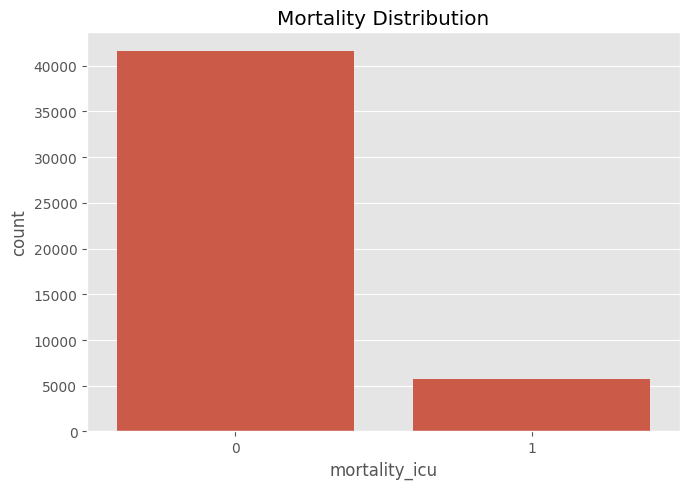

In [33]:
fig, ax = plt.subplots(figsize=(7,5))

# Mortality rate
sns.countplot(x="mortality_icu", data=icu_df, ax=ax)
ax.set_title("Mortality Distribution")

plt.tight_layout()

In [34]:
# Select non-numeric columns
non_numeric_cols = icu_df.select_dtypes(exclude='number')

# Get unique values
for col in non_numeric_cols.columns:
    print(f"{col}: {icu_df[col].unique()}")

gender: ['F' 'M']
race: ['BLACK/AFRICAN AMERICAN' 'WHITE' 'UNABLE TO OBTAIN' 'PORTUGUESE' 'OTHER'
 'UNKNOWN' 'HISPANIC/LATINO - SALVADORAN' 'ASIAN - SOUTH EAST ASIAN'
 'WHITE - OTHER EUROPEAN' 'HISPANIC OR LATINO' 'BLACK/AFRICAN' 'ASIAN'
 'HISPANIC/LATINO - CUBAN' 'BLACK/CAPE VERDEAN' 'ASIAN - CHINESE'
 'WHITE - RUSSIAN' 'BLACK/CARIBBEAN ISLAND' 'HISPANIC/LATINO - DOMINICAN'
 'ASIAN - KOREAN' 'HISPANIC/LATINO - PUERTO RICAN'
 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER'
 'HISPANIC/LATINO - GUATEMALAN' 'WHITE - EASTERN EUROPEAN'
 'AMERICAN INDIAN/ALASKA NATIVE' 'ASIAN - ASIAN INDIAN'
 'HISPANIC/LATINO - HONDURAN' 'PATIENT DECLINED TO ANSWER'
 'HISPANIC/LATINO - CENTRAL AMERICAN' 'SOUTH AMERICAN'
 'MULTIPLE RACE/ETHNICITY' 'WHITE - BRAZILIAN' 'HISPANIC/LATINO - MEXICAN'
 'HISPANIC/LATINO - COLUMBIAN']
admission_location: ['EMERGENCY ROOM' 'PHYSICIAN REFERRAL' 'TRANSFER FROM HOSPITAL'
 'PROCEDURE SITE' 'WALK-IN/SELF REFERRAL' 'INFORMATION NOT AVAILABLE'
 'CLINIC REFERRAL' 'PACU' 'TRANSFER 

In [35]:
def clean_race(race):
    race = race.upper()
    
    if "WHITE" in race:
        return "White"
    
    elif "BLACK" in race:
        return "Black"
    
    elif "ASIAN" in race:
        return "Asian"
    
    elif "HISPANIC" in race or "LATINO" in race:
        return "Hispanic"
    
    elif "AMERICAN INDIAN" in race or "ALASKA" in race:
        return "Native American"
    
    elif "PACIFIC ISLANDER" in race or "HAWAIIAN" in race:
        return "Pacific Islander"
    
    elif race in ["UNKNOWN", "UNABLE TO OBTAIN", "PATIENT DECLINED TO ANSWER"]:
        return "Unknown"
    
    else:
        return "Other"
    
def clean_careunit(unit):

    if "MICU/SICU" in unit:
        return "Mixed ICU"
    
    elif "MICU" in unit:
        return "MICU"
    
    elif "SICU" in unit and "TRAUMA" not in unit.upper():
        return "SICU"
    
    elif "TSICU" in unit or "TRAUMA" in unit.upper():
        return "Trauma ICU"
    
    elif "CCU" in unit or "CVICU" in unit:
        return "Cardiac ICU"
    
    elif "NEURO" in unit:
        if "STEPDOWN" in unit or "INTERMEDIATE" in unit:
            return "Neuro Stepdown"
        return "Neuro ICU"
    
    elif "ICU" in unit:
        return "General ICU"
    
    elif unit in ["PACU"]:
        return "PACU"
    
    elif unit in ["Medicine", "Surgery/Trauma"]:
        return "Ward"
    
    else:
        return "Other"
    
def clean_admission_location(loc):

    if not isinstance(loc, str):
        return "Unknown"

    loc = loc.upper()

    if "EMERGENCY" in loc:
        return "Emergency"

    elif "PHYSICIAN REFERRAL" in loc or "CLINIC REFERRAL" in loc:
        return "Clinic Referral"

    elif "SELF REFERRAL" in loc or "WALK-IN" in loc:
        return "Self Referral"

    elif "TRANSFER FROM HOSPITAL" in loc or "TRANSFER FROM SKILLED NURSING FACILITY" in loc:
        return "External Transfer"

    elif "INTERNAL TRANSFER" in loc:
        return "Internal Transfer"

    elif "PROCEDURE" in loc or "PACU" in loc or "SURGERY" in loc:
        return "Post Procedure"

    elif "INFORMATION NOT AVAILABLE" in loc:
        return "Unknown"

    else:
        return "Other"

In [36]:
icu_df["race_clean"] = icu_df["race"].apply(clean_race)
icu_df.head()

,stay_id,age,gender,race,admission_location,first_careunit,mortality_icu,los,max_hr,min_hr,...,min_potassium,mean_potassium,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h,race_clean
0,39765666,73,F,BLACK/AFRICAN AMERICAN,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),0,0.497535,80.0,68.0,...,4.2,4.300000,46.0,38.0,41.500000,223.0,188.0,212.500000,4300.0,Black
1,37067082,55,F,WHITE,EMERGENCY ROOM,Surgical Intensive Care Unit (SICU),0,1.118032,106.0,78.0,...,3.6,3.733333,9.0,7.0,8.000000,362.0,285.0,312.666667,2745.0,White
2,34592300,55,F,WHITE,PHYSICIAN REFERRAL,Surgical Intensive Care Unit (SICU),0,0.948113,96.0,66.0,...,4.2,4.250000,11.0,10.0,10.500000,299.0,289.0,294.000000,2475.0,White
3,39698942,73,M,WHITE,TRANSFER FROM HOSPITAL,Medical/Surgical Intensive Care Unit (MICU/SICU),1,0.825266,155.0,90.0,...,3.7,4.550000,33.0,33.0,33.000000,609.0,609.0,609.000000,215.0,White
4,32358465,80,F,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),1,0.858576,142.0,75.0,...,5.4,5.633333,48.0,47.0,47.666667,268.0,268.0,268.000000,310.0,White


In [37]:
icu_df["race_clean"].unique()

array(['Black', 'White', 'Unknown', 'Other', 'Hispanic', 'Asian',
       'Pacific Islander', 'Native American'], dtype=object)

In [38]:
icu_df["careunit"] = icu_df["first_careunit"].apply(clean_careunit)
print(icu_df["careunit"].unique())
icu_df.head()

['MICU' 'SICU' 'Mixed ICU' 'Cardiac ICU' 'Other' 'Trauma ICU' 'PACU'
 'General ICU' 'Ward']


,stay_id,age,gender,race,admission_location,first_careunit,mortality_icu,los,max_hr,min_hr,...,mean_potassium,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h,race_clean,careunit
0,39765666,73,F,BLACK/AFRICAN AMERICAN,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),0,0.497535,80.0,68.0,...,4.300000,46.0,38.0,41.500000,223.0,188.0,212.500000,4300.0,Black,MICU
1,37067082,55,F,WHITE,EMERGENCY ROOM,Surgical Intensive Care Unit (SICU),0,1.118032,106.0,78.0,...,3.733333,9.0,7.0,8.000000,362.0,285.0,312.666667,2745.0,White,SICU
2,34592300,55,F,WHITE,PHYSICIAN REFERRAL,Surgical Intensive Care Unit (SICU),0,0.948113,96.0,66.0,...,4.250000,11.0,10.0,10.500000,299.0,289.0,294.000000,2475.0,White,SICU
3,39698942,73,M,WHITE,TRANSFER FROM HOSPITAL,Medical/Surgical Intensive Care Unit (MICU/SICU),1,0.825266,155.0,90.0,...,4.550000,33.0,33.0,33.000000,609.0,609.0,609.000000,215.0,White,Mixed ICU
4,32358465,80,F,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),1,0.858576,142.0,75.0,...,5.633333,48.0,47.0,47.666667,268.0,268.0,268.000000,310.0,White,MICU


In [39]:
icu_df["admission_loc"] = icu_df["admission_location"].apply(clean_admission_location)
print(icu_df["admission_loc"].unique())
icu_df.head()

['Emergency' 'Clinic Referral' 'External Transfer' 'Post Procedure'
 'Self Referral' 'Unknown' 'Internal Transfer']


,stay_id,age,gender,race,admission_location,first_careunit,mortality_icu,los,max_hr,min_hr,...,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h,race_clean,careunit,admission_loc
0,39765666,73,F,BLACK/AFRICAN AMERICAN,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),0,0.497535,80.0,68.0,...,46.0,38.0,41.500000,223.0,188.0,212.500000,4300.0,Black,MICU,Emergency
1,37067082,55,F,WHITE,EMERGENCY ROOM,Surgical Intensive Care Unit (SICU),0,1.118032,106.0,78.0,...,9.0,7.0,8.000000,362.0,285.0,312.666667,2745.0,White,SICU,Emergency
2,34592300,55,F,WHITE,PHYSICIAN REFERRAL,Surgical Intensive Care Unit (SICU),0,0.948113,96.0,66.0,...,11.0,10.0,10.500000,299.0,289.0,294.000000,2475.0,White,SICU,Clinic Referral
3,39698942,73,M,WHITE,TRANSFER FROM HOSPITAL,Medical/Surgical Intensive Care Unit (MICU/SICU),1,0.825266,155.0,90.0,...,33.0,33.0,33.000000,609.0,609.0,609.000000,215.0,White,Mixed ICU,External Transfer
4,32358465,80,F,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),1,0.858576,142.0,75.0,...,48.0,47.0,47.666667,268.0,268.0,268.000000,310.0,White,MICU,Emergency


/scratch/local/27047429/ipykernel_694255/3964294534.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


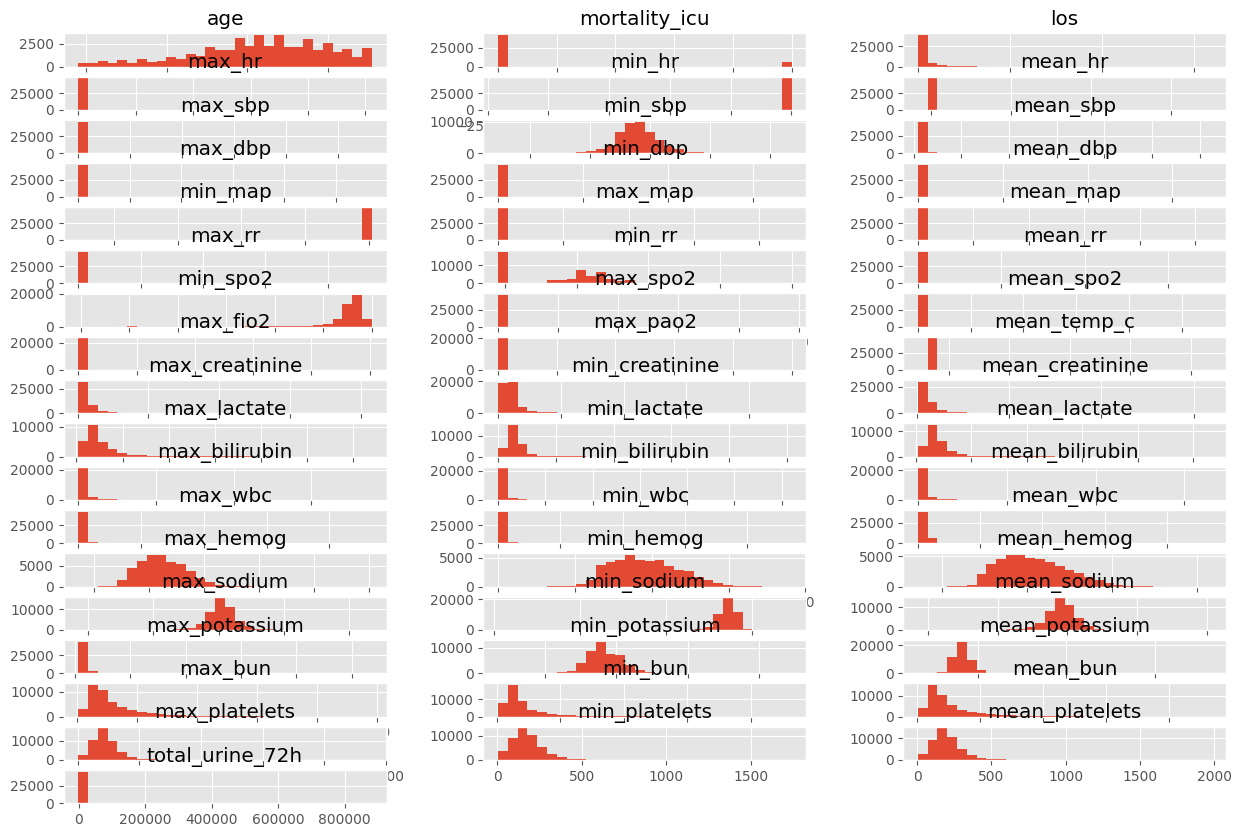

In [40]:
import matplotlib.pyplot as plt

num_cols = icu_df.select_dtypes(include='number').drop([('stay_id')], axis=1).columns

icu_df[num_cols].hist(
    bins=30,
    figsize=(15,10),
    layout=(len(num_cols)//3 + 1, 3)
)

plt.tight_layout()
plt.show()

#### I'm thinking to go with random forest and gradient boosting so I 'm not scaling it as this model doesn't depend on scaled features unlike SVM, Logistic regression. I would be proceeding with doing one hot encoding on my categorical columns and drop stayid as it's just an unique identifier doesn't help in prediction.

In [41]:
icu_df["stay_id"].nunique()

47291

In [ ]:
# correct the drop call – give a list of column names, not a tuple
icu_final_df = icu_df.drop(
    ['stay_id', 'race', 'admission_location', 'first_careunit'],
    axis=1
)

# make sure the target folder exists
outdir = Path("mimic dataset")           # or Path("/mimic dataset") if you really need an absolute path
outdir.mkdir(parents=True, exist_ok=True)

icu_final_df.to_csv(outdir / "icu_final_df.csv", index=False)
icu_final_df.head()

,age,gender,mortality_icu,los,max_hr,min_hr,mean_hr,max_sbp,min_sbp,mean_sbp,...,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h,race_clean,careunit,admission_loc
0,73,F,0,0.497535,80.0,68.0,73.636364,158.0,130.0,142.454545,...,46.0,38.0,41.500000,223.0,188.0,212.500000,4300.0,Black,MICU,Emergency
1,55,F,0,1.118032,106.0,78.0,93.296296,153.0,117.0,136.296296,...,9.0,7.0,8.000000,362.0,285.0,312.666667,2745.0,White,SICU,Emergency
2,55,F,0,0.948113,96.0,66.0,79.600000,167.0,94.0,115.869565,...,11.0,10.0,10.500000,299.0,289.0,294.000000,2475.0,White,SICU,Clinic Referral
3,73,M,1,0.825266,155.0,90.0,123.294118,114.0,72.0,91.294118,...,33.0,33.0,33.000000,609.0,609.0,609.000000,215.0,White,Mixed ICU,External Transfer
4,80,F,1,0.858576,142.0,75.0,115.979167,126.0,66.0,98.735294,...,48.0,47.0,47.666667,268.0,268.0,268.000000,310.0,White,MICU,Emergency


In [44]:
cat_cols = icu_final_df.select_dtypes(include='object').columns
print("Categorical columns:", cat_cols)

Categorical columns: Index(['gender', 'race_clean', 'careunit', 'admission_loc'], dtype='object')
